# RNA para Regresión con Diabetes

Demo simple de red neuronal artificial en Keras para un problema de regresión.


## 1. Importar librerías


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf
import random

In [2]:
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

## 2. Cargar dataset
El objetivo es predecir una medida cuantitativa de progresión de diabetes.


In [3]:
data = load_diabetes()
X = data.data
y = data.target

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
print("Primeros 5 valores objetivo:", y[:5])


Forma de X: (442, 10)
Forma de y: (442,)
Primeros 5 valores objetivo: [151.  75. 141. 206. 135.]


## 3. Separar entrenamiento y validación


In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Entrenamiento:", X_train.shape, y_train.shape)
print("Validación:", X_val.shape, y_val.shape)


Entrenamiento: (353, 10) (353,)
Validación: (89, 10) (89,)


## 4. Estandarizar variables


In [5]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)


## 5. Crear la red neuronal
Como es regresión, la salida es una sola neurona sin función de activación.


In [6]:
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Compilar modelo


In [7]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)


## 7. Entrenar modelo


In [8]:
history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=16,
    validation_data=(X_val, y_val),
    verbose=1
)


Epoch 1/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 29592.5605 - mae: 153.3820 - val_loss: 26243.7871 - val_mae: 144.7548
Epoch 2/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 29194.4727 - mae: 152.0931 - val_loss: 25762.1484 - val_mae: 143.1320
Epoch 3/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 28535.6543 - mae: 150.0212 - val_loss: 24933.4414 - val_mae: 140.3746
Epoch 4/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 27412.1699 - mae: 146.5065 - val_loss: 23567.7305 - val_mae: 135.8298
Epoch 5/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 25604.1465 - mae: 140.7630 - val_loss: 21459.5879 - val_mae: 128.6220
Epoch 6/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 22919.7773 - mae: 131.8337 - val_loss: 18506.7207 - val_mae: 117.8650
Epoch 7/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 19354.8672 - mae: 119.0952 - val_loss: 14885.7471 - val_mae: 103.3933
Epoch 8/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 15271.3203 - mae: 102.7489 - val_loss: 111

## 8. Evaluar modelo


In [9]:
loss, mae = model.evaluate(X_val, y_val, verbose=0)
print(f"MAE (Keras): {mae:.4f}")


MAE (Keras): 43.0902


## 9. Predicciones y métricas


In [10]:
y_pred = model.predict(X_val).ravel()

mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
MAE:  43.0902
MSE:  2821.7282
RMSE: 53.1199
R²:   0.4674


## 10. Graficar entrenamiento


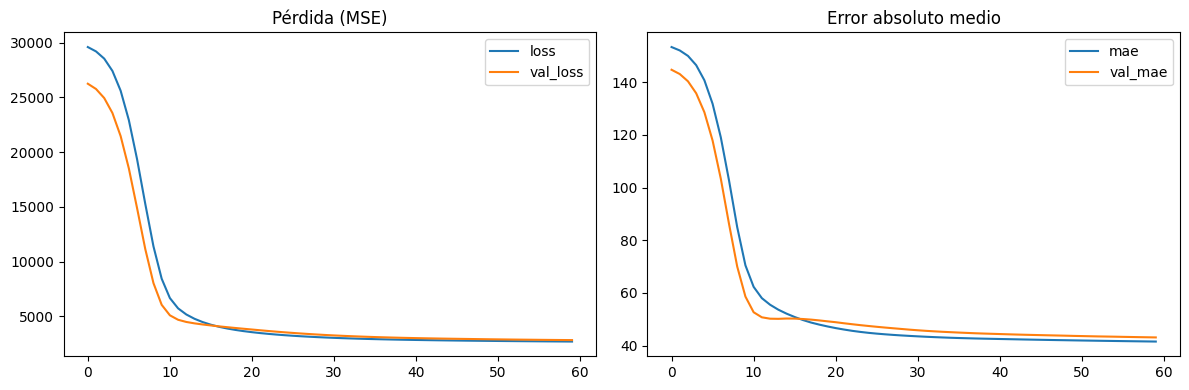

In [11]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Pérdida (MSE)")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["mae"], label="mae")
plt.plot(history.history["val_mae"], label="val_mae")
plt.title("Error absoluto medio")
plt.legend()

plt.tight_layout()
plt.show()


## 11. Comparar valores reales vs predichos


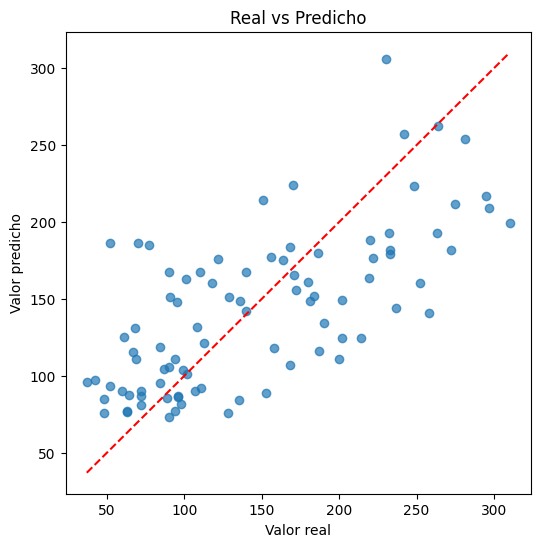

In [12]:
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred, alpha=0.7)
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("Real vs Predicho")
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], "r--")
plt.show()


## 12. Probar algunas predicciones


In [13]:
for i in range(5):
    print(f"Real: {y_val[i]:.2f} | Predicho: {y_pred[i]:.2f}")


Real: 219.00 | Predicho: 163.48
Real: 70.00 | Predicho: 186.04
Real: 202.00 | Predicho: 149.57
Real: 230.00 | Predicho: 306.15
Real: 111.00 | Predicho: 92.35


# Búsqueda de hiperparámetros usando GridSearchCV

In [14]:
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
# -----------------------
# Cargar datos
# -----------------------
data = load_diabetes()
X = data.data
y = data.target

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------
# Escalar variables
# -----------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# -----------------------
# Función del modelo
# -----------------------
def build_model(neurons1=32, neurons2=16, learning_rate=0.001):

    model = keras.Sequential([
        layers.Dense(neurons1, activation="relu", input_shape=(X_train.shape[1],)),
        layers.Dense(neurons2, activation="relu"),
        layers.Dense(1)
    ])

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="mse",
        metrics=["mae"]
    )

    return model

# -----------------------
# Modelo sklearn
# -----------------------
model = KerasRegressor(model=build_model, verbose=0)

# -----------------------
# Hiperparámetros
# -----------------------
param_grid = {

    "model__neurons1": [16, 32, 64],
    "model__neurons2": [8, 16, 32],

    "batch_size": [8, 16, 32],
    "epochs": [50, 100],

    "model__learning_rate": [0.01, 0.001]
}

# -----------------------
# Grid Search
# -----------------------
grid = GridSearchCV(

    estimator=model,
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Mejores parámetros:")
print(grid.best_params_)

# -----------------------
# Evaluar mejor modelo
# -----------------------
best_model = grid.best_estimator_

y_pred = best_model.predict(X_val)

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print("\nResultados:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

c:\Users\cotec\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
c:\Users\cotec\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Mejores parámetros:
{'batch_size': 8, 'epochs': 50, 'model__learning_rate': 0.001, 'model__neurons1': 32, 'model__neurons2': 32}

Resultados:
MAE: 42.01383582125889
RMSE: 52.531830113275284
R2: 0.4791404047982095


# Búsqueda de hiperparámetros usando RandomizedSearchCV

In [15]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from scikeras.wrappers import KerasRegressor

from tensorflow import keras
from tensorflow.keras import layers

# -----------------------
# Cargar datos
# -----------------------
data = load_diabetes()
X = data.data
y = data.target

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------
# Escalar variables
# -----------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# -----------------------
# Modelo
# -----------------------
def build_model(neurons1=32, neurons2=16, learning_rate=0.001):

    model = keras.Sequential([
        layers.Dense(neurons1, activation="relu", input_shape=(X_train.shape[1],)),
        layers.Dense(neurons2, activation="relu"),
        layers.Dense(1)
    ])

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="mse",
        metrics=["mae"]
    )

    return model

model = KerasRegressor(model=build_model, verbose=0)

# -----------------------
# Parámetros
# -----------------------
param_dist = {

    "model__neurons1": [16, 32, 64],
    "model__neurons2": [8, 16, 32],

    "batch_size": [8, 16, 32],
    "epochs": [50, 80, 100],

    "model__learning_rate": [0.01, 0.001, 0.0005]
}

# -----------------------
# Random Search
# -----------------------
random = RandomizedSearchCV(

    estimator=model,
    param_distributions=param_dist,

    n_iter=10,
    cv=3,

    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1
)

random.fit(X_train, y_train)

print("Mejores parámetros:")
print(random.best_params_)

# -----------------------
# Evaluación
# -----------------------
best_model = random.best_estimator_

y_pred = best_model.predict(X_val)

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print("\nResultados:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

c:\Users\cotec\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Mejores parámetros:
{'model__neurons2': 8, 'model__neurons1': 64, 'model__learning_rate': 0.001, 'epochs': 100, 'batch_size': 16}

Resultados:
MAE: 42.395416602659765
RMSE: 52.369148257090316
R2: 0.4823614310516926
